# Data Visualization 

1. prepare data for visualization 
2. anlyiz number of rides by 
   1. season
   2. month
   3. compare with weather conditions
3. Visualize Top Start Stations
4. Visualize Top End Stations
5. Homework Part 2

[Step 12-15](https://hovhannisyan91.github.io/aca/materials/python/session15.html#step-12-getting-weather-data)

## Loading Libraries

In [1]:

import requests

import numpy as np
import pandas as pd

import plotly.express as px
import folium

import os
from pathlib import Path
from urllib.request import urlretrieve
from urllib.error import HTTPError, URLError
from zipfile import ZipFile

In [2]:
OUTPUT_DIR = "../data/citibike/"

In [3]:
# PUT your CODE
df_citibike = pd.read_csv("../data/citibike/JC/JC2022_Enriched.csv")
df_citibike.columns

Index(['ride_id', 'rideable_type', 'started_at', 'ended_at',
       'start_station_name', 'start_station_id', 'end_station_name',
       'end_station_id', 'start_lat', 'start_lng', 'end_lat', 'end_lng',
       'member_casual', 'ride_duration_minutes', 'date', 'month', 'month_name',
       'day_of_week', 'hour', 'season'],
      dtype='str')



| Колонка | Что это |
|---|---|
| `ride_id` | Уникальный ID поездки |
| `rideable_type` | Тип велосипеда (classic/electric) |
| `started_at` | Дата и время начала |
| `ended_at` | Дата и время конца |
| `start_station_name` | Название станции отправления |
| `start_station_id` | ID станции отправления |
| `end_station_name` | Название станции прибытия |
| `end_station_id` | ID станции прибытия |
| `start_lat/lng` | Координаты начала |
| `end_lat/lng` | Координаты конца |
| `member_casual` | Тип пользователя (подписчик/гость) |
| `ride_duration_minutes` | Длительность поездки в минутах |
| `date` | Дата поездки |
| `month` | Номер месяца |
| `month_name` | Название месяца |
| `day_of_week` | День недели |
| `hour` | Час начала поездки |
| `season` | Сезон (весна/лето/осень/зима) |

# Season Data

In [4]:
season_data = df_citibike.groupby("season")["ride_id"].count()
season_data 

season
Autumn    260293
Spring    190658
Summer    213506
Winter     78307
Name: ride_id, dtype: int64

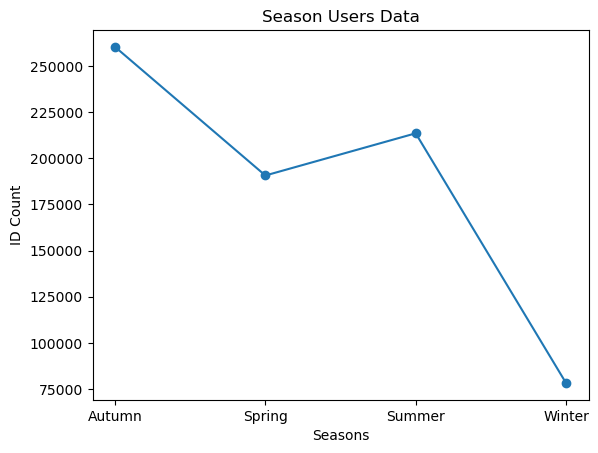

In [5]:
# PUT youR code
import matplotlib.pyplot as plt
season_data

plt.figure()
plt.plot(season_data.index, season_data.values, marker="o")
plt.title("Season Users Data")
plt.xlabel("Seasons")
plt.ylabel("ID Count")
plt.show()

#! ADD as many chunks as you need

## Monthly Data

In [6]:
monthly_data = df_citibike.groupby("month")["ride_id"].count()
monthly_data

month
2022-02     31210
2022-03     50673
2022-04     61228
2022-05     78757
2022-06    100908
2022-08    112598
2022-09    101898
2022-10     87472
2022-11     70923
2022-12     47097
Name: ride_id, dtype: int64

### Visualizations based on **Montly Data**

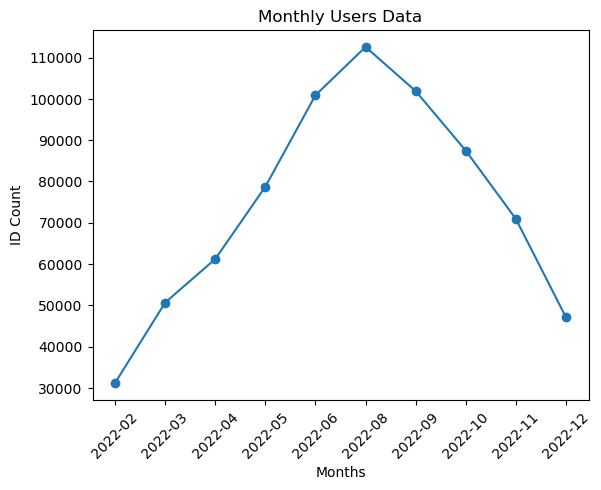

In [7]:
# PUT youR code
import matplotlib.pyplot as plt
monthly_data

plt.figure()
plt.plot(monthly_data.index, monthly_data.values, marker="o")
plt.title("Monthly Users Data")
plt.xlabel("Months")
plt.xticks(rotation=45)
plt.ylabel("ID Count")
plt.show()

#! ADD as many chunks as you need

# Bar Plot top 10 stations:

In [8]:
best_start = df_citibike.groupby("start_station_name")["ride_id"].count().sort_values(ascending=False).head(10)
best_start

start_station_name
Grove St PATH                                   35337
South Waterfront Walkway - Sinatra Dr & 1 St    28225
Hoboken Terminal - River St & Hudson Pl         27166
Hoboken Terminal - Hudson St & Hudson Pl        24948
City Hall - Washington St & 1 St                19575
Newport Pkwy                                    17753
Newport PATH                                    17191
Hamilton Park                                   16742
Hoboken Ave at Monmouth St                      16186
Marin Light Rail                                15588
Name: ride_id, dtype: int64

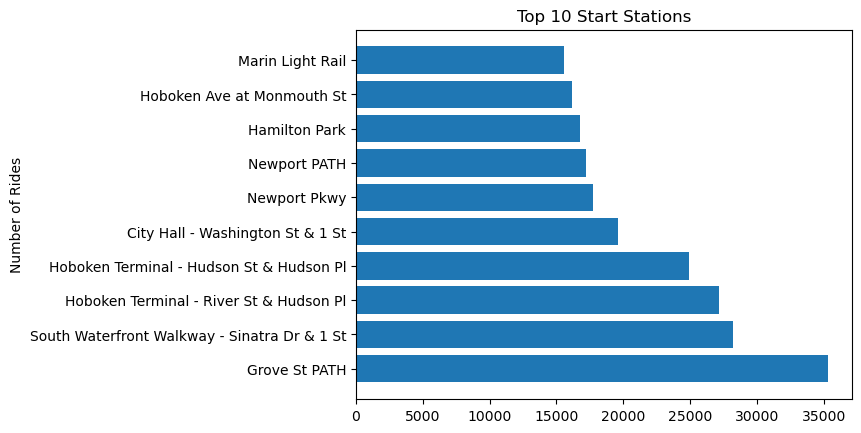

In [9]:
plt.figure()
plt.barh(best_start.index, best_start.values)
plt.title("Top 10 Start Stations")
plt.ylabel("Number of Rides")
plt.show()

In [10]:
best_end = df_citibike.groupby("end_station_name")["ride_id"].count().sort_values(ascending=False).head(10)
best_start

start_station_name
Grove St PATH                                   35337
South Waterfront Walkway - Sinatra Dr & 1 St    28225
Hoboken Terminal - River St & Hudson Pl         27166
Hoboken Terminal - Hudson St & Hudson Pl        24948
City Hall - Washington St & 1 St                19575
Newport Pkwy                                    17753
Newport PATH                                    17191
Hamilton Park                                   16742
Hoboken Ave at Monmouth St                      16186
Marin Light Rail                                15588
Name: ride_id, dtype: int64

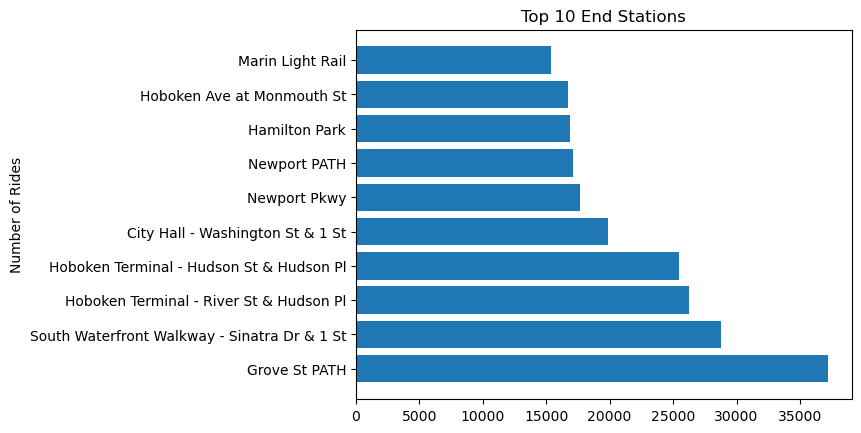

In [11]:
plt.figure()
plt.barh(best_end.index, best_end.values)
plt.title("Top 10 End Stations")
plt.ylabel("Number of Rides")
plt.show()

# compare with weather conditions

In [12]:
weather_df = pd.read_csv("../data/citibike/JC/jersey_weather_2022.csv")
weather_df.columns

Index(['temperature_2m_max', 'temperature_2m_min', 'temperature_2m_mean',
       'precipitation_sum', 'rain_sum', 'snowfall_sum', 'wind_speed_10m_max',
       'date'],
      dtype='str')

In [13]:
daily_rides = (
    df_citibike
    .groupby("date", as_index=False)
    .agg(
        number_of_rides=("ride_id", "count")
    )
)
daily_rides["date"] = pd.to_datetime(daily_rides["date"])
daily_rides.head()

,date,number_of_rides
0,2022-02-01,752
1,2022-02-02,1018
2,2022-02-03,642
3,2022-02-04,485
4,2022-02-05,779


In [14]:
weather_df.head()

,temperature_2m_max,temperature_2m_min,temperature_2m_mean,precipitation_sum,rain_sum,snowfall_sum,wind_speed_10m_max,date
0,-5.9,-14.1,-10.4,3.2,0.0,2.24,7.6,2022-01-01
1,-4.2,-17.5,-11.7,0.5,0.0,0.35,9.7,2022-01-02
2,-4.4,-13.5,-8.1,1.5,0.0,1.12,9.3,2022-01-03
3,-5.0,-12.2,-9.2,3.5,0.1,2.38,5.9,2022-01-04
4,-3.1,-16.5,-10.8,0.3,0.0,0.21,7.2,2022-01-05


In [15]:
weather_df["date"] = pd.to_datetime(weather_df["date"])
daily_rides["date"] = pd.to_datetime(daily_rides["date"])

bike_weather_daily = daily_rides.merge(
    weather_df,
    on="date",
    how="left"
)

bike_weather_daily.head()

,date,number_of_rides,temperature_2m_max,temperature_2m_min,temperature_2m_mean,precipitation_sum,rain_sum,snowfall_sum,wind_speed_10m_max
0,2022-02-01,752,-6.9,-23.3,-16.0,0.0,0.0,0.00,8.0
1,2022-02-02,1018,-7.4,-18.1,-12.2,5.4,0.0,3.85,7.8
2,2022-02-03,642,-10.7,-25.4,-16.9,1.6,0.0,1.12,6.2
3,2022-02-04,485,-9.4,-25.9,-18.7,0.0,0.0,0.00,10.2
4,2022-02-05,779,-8.4,-21.9,-15.5,0.0,0.0,0.00,10.0


In [16]:
bike_weather_daily.isna().sum()

date                   0
number_of_rides        0
temperature_2m_max     0
temperature_2m_min     0
temperature_2m_mean    0
precipitation_sum      0
rain_sum               0
snowfall_sum           0
wind_speed_10m_max     0
dtype: int64

In [17]:
fig = px.scatter(
    bike_weather_daily,
    x="temperature_2m_mean",
    y="number_of_rides",
    trendline="ols",
    title="Daily Rides vs Average Temperature"
)

fig.update_layout(
    xaxis_title="Average Daily Temperature",
    yaxis_title="Number of Rides"
)

fig.show()

In [19]:
fig = px.scatter(
    bike_weather_daily,
    x="wind_speed_10m_max",
    y="number_of_rides",
    trendline="ols",
    title="Daily Rides vs Maximum Wind Speed"
)

fig.update_layout(
    xaxis_title="Maximum Wind Speed",
    yaxis_title="Number of Rides"
)

fig.show()

In [20]:
fig = px.scatter(
    bike_weather_daily,
    x="precipitation_sum",
    y="number_of_rides",
    trendline="ols",
    title="Daily Rides vs Precipitation"
)

fig.update_layout(
    xaxis_title="Daily Precipitation",
    yaxis_title="Number of Rides"
)

fig.show()

In [21]:
import plotly.graph_objects as go


fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=bike_weather_daily["date"],
        y=bike_weather_daily["number_of_rides"],
        mode="lines",
        name="Daily Rides",
        yaxis="y1"
    )
)

fig.add_trace(
    go.Scatter(
        x=bike_weather_daily["date"],
        y=bike_weather_daily["temperature_2m_mean"],
        mode="lines",
        name="Daily Average Temperature",
        yaxis="y2"
    )
)

fig.update_layout(
    title="Daily Rides and Daily Average Temperature",
    xaxis=dict(
        title="Day"
    ),
    yaxis=dict(
        title="Daily Rides",
        side="left"
    ),
    yaxis2=dict(
        title="Daily Average Temperature",
        overlaying="y",
        side="right"
    ),
    hovermode="x unified",
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.02,
        xanchor="right",
        x=1
    )
)

fig.show()